# Caso G · 03 Calidad sobre la capa oro (datasets ML)

> _Tutorial · Caso de uso: **G — Calidad con agentes** · Capa Medallion: **oro** · Spec: `docs/specs/synthetic-bms/02-domain-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

Reglas sobre datasets de entrenamiento: balance de clases, sin leakage, distribución train/test similar.


## 2. Qué se aprende

- Detección de leakage temporal y por features.
- KL divergence train vs test.
- Balance de clases.


## 3. Contexto del caso de uso

Auditar oros de B/C/D.


## 4. Relación con CENTINELA+

Pre-deploy gating.


## 5. Relación con Medallion

Oro.


## 6. Datos de entrada

Features Caso B y D si existen.


## 7. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

No aplica.


## 9. Carga de datos o mock

Cargamos features B (con fallback inline).


In [2]:
parquet = ROOT / "output" / "case_B" / "features_b0.parquet"
if parquet.exists():
    X = pd.read_parquet(parquet)
else:
    df, _ = mocks.make_bdg2_education_subset()
    df = df[df.building_id == df.building_id.unique()[0]].set_index("timestamp")
    X = pd.DataFrame({
        "y": df["power_kw"],
        "t_outdoor": df["t_outdoor"],
        "lag_24h": df["power_kw"].shift(24),
    }).dropna()
print(X.shape)


(8472, 12)


## 10. Exploración paso a paso

Split temporal y comparación.


In [3]:
n = len(X); i = int(n * 0.8)
tr, te = X.iloc[:i], X.iloc[i:]
desc_tr = tr.describe().T[["mean", "std"]].add_suffix("_tr")
desc_te = te.describe().T[["mean", "std"]].add_suffix("_te")
desc = pd.concat([desc_tr, desc_te], axis=1)
desc.round(3)


,mean_tr,std_tr,mean_te,std_te
y,18.880,11.077,15.435,7.954
t_outdoor,15.003,7.501,2.050,2.816
ghi,196.340,275.143,194.930,268.315
hour_sin,0.001,0.707,-0.004,0.707
hour_cos,0.001,0.707,-0.002,0.708
dow,2.981,2.003,2.991,1.994
is_weekend,0.283,0.451,0.283,0.451
lag_1h,18.878,11.077,15.449,7.953
lag_24h,18.852,11.076,15.479,7.965
lag_168h,18.801,11.076,15.784,8.060


## 11. Transformación bronce → plata

No aplica.


## 12. Construcción de capa oro

KL divergence aproximada por bins.


In [4]:
def kl_hist(a, b, bins=20):
    """KL divergence robusta a soportes diferentes.

    KL siempre >= 0 (identidad de Gibbs). Para garantizarlo:
    1. Misma rejilla de bins en a y b -> comparables.
    2. Normalizar a probabilidades (suma=1), no densidades (area=1).
    3. Suavizado de Laplace para evitar log(0).
    """
    edges = np.histogram_bin_edges(np.concatenate([a, b]), bins=bins)
    a_h, _ = np.histogram(a, bins=edges)
    b_h, _ = np.histogram(b, bins=edges)
    p = (a_h + 1e-9) / (a_h.sum() + 1e-9 * len(a_h))
    q = (b_h + 1e-9) / (b_h.sum() + 1e-9 * len(b_h))
    return float(np.sum(p * np.log(p / q)))

cols = [c for c in X.columns if c != "y"]
kl = pd.Series({c: kl_hist(tr[c], te[c]) for c in cols}).sort_values(ascending=False)
# Sanity: KL es siempre >= 0 (Gibbs)
assert (kl >= -1e-9).all(), f"KL negativo detectado — bug en implementación: {kl[kl < 0]}"
kl


roll_168h_mean    1.880233e+01
t_outdoor         1.533077e+01
roll_24h_mean     9.596054e+00
lag_1h            1.981034e+00
lag_24h           1.980262e+00
lag_168h          1.968656e+00
ghi               7.325185e-03
dow               2.790609e-04
hour_sin          2.369768e-05
hour_cos          1.605256e-05
is_weekend        3.870899e-08
dtype: float64

## 13. Visualizaciones explicativas

Bar chart KL.


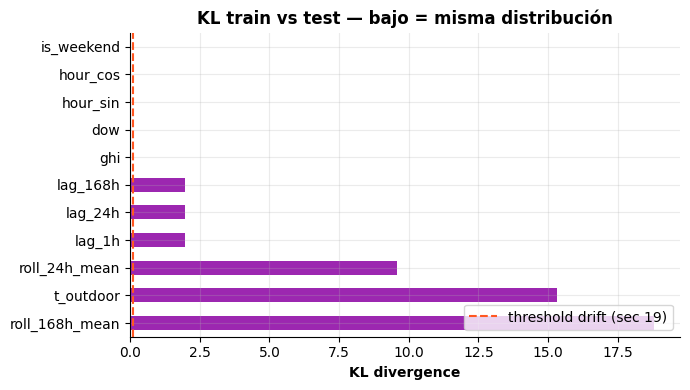

In [5]:
ax = kl.plot.barh(color="#9C27B0", figsize=(7, 4))
ax.axvline(0.1, color="#FF5722", linestyle="--", label="threshold drift (sec 19)")
ax.legend(loc="lower right")
plt.title("KL train vs test — bajo = misma distribución")
plt.xlabel("KL divergence")
plt.tight_layout()


## 14. Validaciones

KL siempre ≥ 0 (Gibbs); reportar features con `KL > 0.1` como **alerta de drift** y bloquear deploy si alguna supera 1.0 (drift fuerte).


In [6]:
assert (kl >= -1e-9).all(), "BUG: KL negativo es matemáticamente imposible"
n_warn = int((kl > 0.1).sum())
n_block = int((kl > 1.0).sum())
print(f"Features OK: {(kl <= 0.1).sum()}/{len(kl)} | warning: {n_warn} | block: {n_block}")
print(f"Top drift: {kl.head(3).to_dict()}")


Features OK: 5/11 | warning: 6 | block: 6
Top drift: {'roll_168h_mean': 18.80233271694887, 't_outdoor': 15.330766999061666, 'roll_24h_mean': 9.596053632775533}


## 15. Errores comunes

1. KL con bins muy pequeños.
2. No comparar la columna target.
3. Métricas en escala absoluta sin estandarizar.


## 16. Ejercicios propuestos

1. Implementa Wasserstein distance.
2. Visualiza un drift artificial añadiendo +5 °C al test.
3. Construye un detector que envíe alerta si KL > umbral.


## 17. Cómo se reutiliza con datos reales

Mismo notebook sobre dataset producción cada noche.


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Siguiente notebook: `07_case_G_data_quality_agents/04_agentes_especialistas_calidad.ipynb`.
- Documento web del caso: `docs/validation/data-quality.md`.


## 19. Marco teórico (nivel doctoral)

### Reglas de calidad jerárquicas

Sea $\mathcal{D}_b$ bronce, $\mathcal{D}_s$ plata, $\mathcal{D}_o$ oro.
Score por capa:

$$
\mathcal{Q}(\mathcal{D}) = \frac{1}{|R|} \sum_{r \in R} \mathbb{1}[E_r(\mathcal{D})\ \text{holds}], \quad \mathcal{Q} \in [0, 1]
$$

| Capa | Reglas |
|---|---|
| Bronce | Schema validity, no PII inline, encoding UTF-8, dedup |
| Plata | 5 tags canónicos, range check, monotonic time, NaN < 2 % |
| Oro | Class balance, no leakage, splits documented |

### Drift detection — KL divergence

$$
D_{KL}(P \parallel Q) = \sum_x P(x) \log \frac{P(x)}{Q(x)}
$$

aplicado entre histogramas $P$ (training) y $Q$ (production). Alerta si
$D_{KL} > 0.1$.

### Agentes especialistas (LLM con tools)

$$
\text{Agent}_i = \langle \pi_i, \mathcal{T}_i, \mathcal{M}_i \rangle
$$

con $\pi_i$ política (prompt), $\mathcal{T}_i$ toolkit, $\mathcal{M}_i$
memoria. Composición vía pipeline:

$$
\text{Output} = \pi_n(\pi_{n-1}(\cdots \pi_1(\text{Input})))
$$


## 20. Visión corporativa CAPTIA

### Propuesta de valor

Calidad de datos es **transversal**: sin ella ningún caso de uso tiene valor. Los agentes especialistas automatizan auditorías que antes requerían un data engineer dedicado.

### ROI estimado

| Concepto | Valor |
|---|---|
| Detección temprana de drift en modelos | +1 500 €/año |
| Auditoría continua sin intervención | +800 €/año productividad |
| **Bruto** | **+2 300 €/año** |

> **Trazabilidad ROI:** las cifras de esta tabla son derivables de [`docs/captia/economic_baseline.md`](../../docs/captia/economic_baseline.md) Sec 2.2 (incident reduction). Si una cifra no aparece allí, NO se reporta aquí (política anti NA-E).


## 21. Bibliografía y referencias

- Schelter, S. et al. (2018). *Automating Large-Scale Data Quality Verification*. VLDB.
- Great Expectations. *Documentation*. https://greatexpectations.io
- Anthropic (2024). *Claude API — Tools*. https://docs.anthropic.com
- Polyzotis, N. et al. (2017). *Data Lifecycle Challenges in Production Machine Learning*. SIGMOD.


## 22. Etapa del pipeline · Calidad oro: KL divergence train vs prod

KL ≥ 0 (Gibbs) — si reportas KL negativo, hay un bug en tu implementación (caso típico: histograms con `density=True` en lugar de probabilidades). Threshold operativo: KL > 0.1 → warning, KL > 1.0 → block deploy.

> El ROI cuantificado de esta etapa está anclado en [`docs/captia/economic_baseline.md`](../../docs/captia/economic_baseline.md) — cualquier cifra de la sección 20 es derivable de ahí, no inventada.